# 04_06 Drainage Network Extraction (From Flow Accumulation)

This notebook extracts a **drainage network** from the previously computed flow accumulation field.

While flow accumulation provides a continuous representation of how water converges across a terrain surface, it does not explicitly define where channelized flow begins.

Drainage network extraction converts this continuous field into a **discrete hydrological structure**, identifying the locations where accumulated flow exceeds a defined threshold and channel-like behavior emerges.

### Conceptual Relationship

Flow accumulation represents a *potential field*:

- Every cell contributes flow downstream
- Values increase where many upstream paths converge

However, this field alone does not define a river system.

To extract structure, we apply a threshold:

$$
\text{Drainage Network} = A(x, y) > T
$$

Where:

- $A(x, y)$ = flow accumulation at a cell
- $T$ = chosen threshold
- Output = binary stream / drainage mask

### Why thresholding works

In natural terrain systems, drainage channels form where contributing area becomes large enough that overland flow concentrates.

This produces a strong contrast between:

- diffuse hillslope flow (low accumulation)
- channelized flow (high accumulation)

Thresholding isolates this transition zone.

## 2. Imports

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio

## 3. Load Data

In [35]:
with rasterio.open("../../data/Elevation/clipped_dem.tif") as src:
    dem = src.read(1)
    bounds = src.bounds
    nodata = src.nodata

dem = np.where(dem == nodata, np.nan, dem)

## 4. Compute Flow Accumulation Field

In [36]:
# --- spatial scaling ---
rows, cols = dem.shape

mean_lat = (bounds.top + bounds.bottom) / 2

lat_m = 111320
lon_m = 111320 * np.cos(np.radians(mean_lat))

dx_spacing = lon_m * (bounds.right - bounds.left) / cols
dy_spacing = lat_m * (bounds.top - bounds.bottom) / rows

# --- terrain gradient ---
dy, dx = np.gradient(
    dem,
    dy_spacing,
    dx_spacing
)

# --- D8 flow directions ---
flow_dx = -dx
flow_dy = -dy

# --- Nearest neighbour direction indices ---
row_offset = np.sign(
    np.nan_to_num(flow_dy)
).astype(int)

col_offset = np.sign(
    np.nan_to_num(flow_dx)
).astype(int)

# initialize accumulation
flow_acc = np.ones_like(dem)

# process highest elevations first
flat_indices = np.dstack(
    np.unravel_index(
        np.argsort(-dem.ravel()),
        dem.shape
    )
)[0]

for r, c in flat_indices:

    if np.isnan(dem[r, c]):
        continue

    rr = r + row_offset[r, c]
    cc = c + col_offset[r, c]

    if (
        0 <= rr < rows and
        0 <= cc < cols and
        not np.isnan(dem[rr, cc])
    ):
        flow_acc[rr, cc] += flow_acc[r, c]

flow_acc = np.ma.masked_invalid(flow_acc)

## 5. Define Drainage Threshold

Adjust this threshold from 95-99%. This tells you what percentage of the range of values is filtered out. So if 99% is filtered out, then you will only see the top 1% of values. 

In [37]:
# percentile-based threshold (robust for varying landscapes)

threshold = np.nanpercentile(flow_acc.compressed(), 98)

drainage = flow_acc > threshold

## 6. Visualization (Drainage Network)

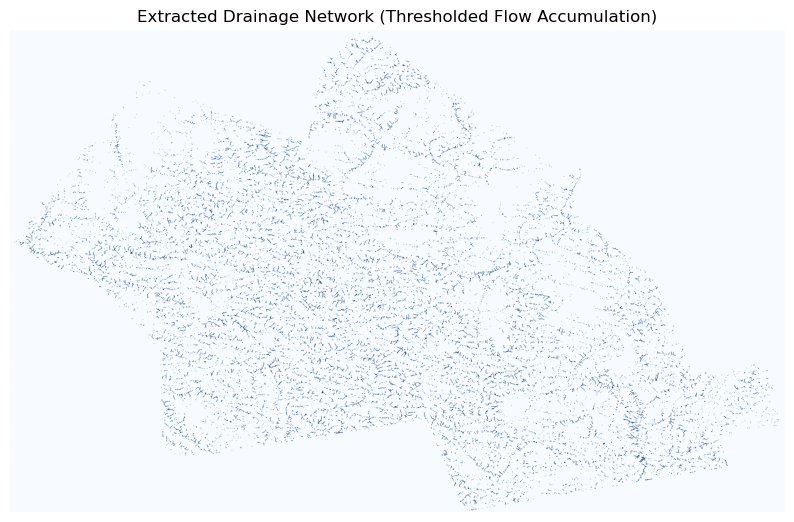

In [38]:
plt.figure(figsize=(10, 10))

plt.imshow(
    drainage,
    cmap="Blues",
    origin="upper"
)

plt.title("Extracted Drainage Network (Thresholded Flow Accumulation)")
plt.axis("off")

plt.show()

## 7. Drainage Network Threshold Comparison

This section features a drainage network comparison for different threshold values.

This teaches something important:

- Drainage networks are contextual
- How we define them depends on how much contributing accumulation area we require before we call something a channel.
- If you are looking for hidden layers that are not easily detected by the human perception of terrain (like smaller accumulation, low flow areas) then you might have a lower threshold value.

<Figure size 1000x1000 with 0 Axes>

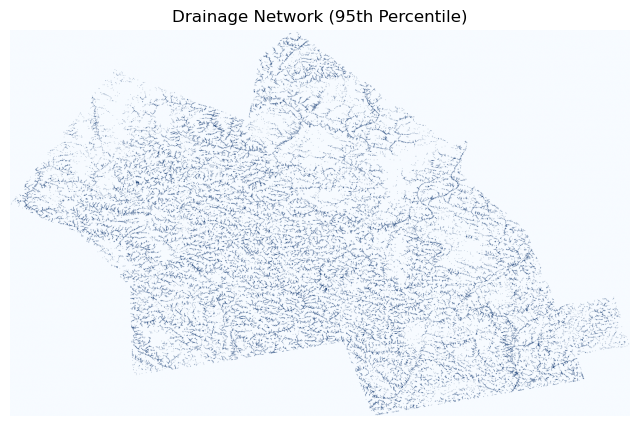

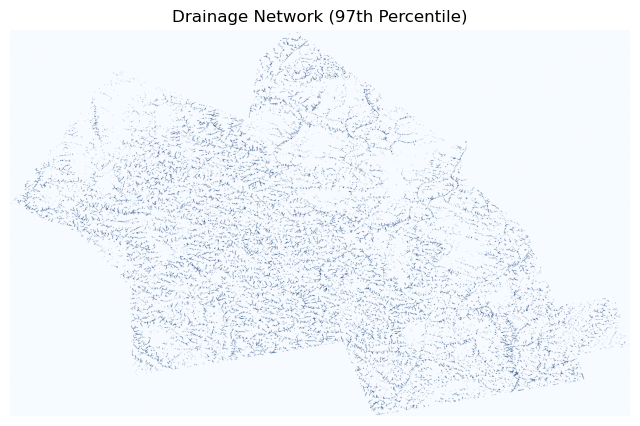

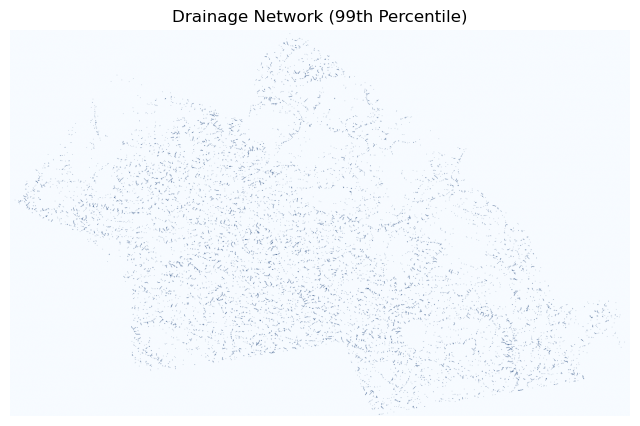

In [40]:
plt.figure(figsize=(10, 10))

for p in [95, 97, 99]:
    threshold = np.nanpercentile(
        flow_acc.compressed(),
        p
    )

    drainage = flow_acc > threshold

    plt.figure(figsize=(8,8))
    plt.imshow(drainage, cmap="Blues")
    plt.title(f"Drainage Network ({p}th Percentile)")
    plt.axis("off")
    plt.show()
    

## 8. Interpretation

The extracted drainage network represents locations where flow convergence exceeds a threshold.

Key observations:

- Low accumulation areas correspond to hillslopes and diffuse runoff zones
- High accumulation areas form connected channel-like structures
- In the Waterloo Region dataset, these structures align strongly with:
  - the Grand River system
  - secondary tributary channels
  - subtle drainage pathways within the Waterloo Moraine

Importantly, these channels are not explicitly drawn from vector data — they emerge directly from terrain geometry through accumulation dynamics.

### Hydrological meaning

This step transitions the analysis from continuous fields to discrete structure.

- Flow accumulation → continuous convergence field
- Drainage network → extracted hydrological skeleton



## 9. Conclusion

This notebook demonstrates how drainage networks can be derived directly from a digital elevation model using flow accumulation thresholding.

The resulting structure provides a simplified representation of surface water routing, forming the basis for:
- watershed delineation
- river network modeling
- ecological drainage analysis

Drainage networks are contextual:

How we define them depends on how much contributing accumulation area we require before we call something a channel. If you are looking for hidden layers that are not easily detected by the human perception of terrain (like smaller accumulation, low flow areas) then you might have a lower threshold value. If you are trying to filter out low flow areas and visual noise or identify only major drainage networks then you can use a higher threshold. 